# Disentanglement

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

The effect size is small. Note how only 35.4% of questions has multiple answers in WQ, while NQ has merely 9.8%.

In [2]:
def analyze_label_distribution() -> None:
    for dataset in ("webquestions", "nq"):
        path = Path("../data") / dataset / f"{dataset}-train.jsonl"
        df = pd.read_json(path, lines=True)
        print(dataset)
        ans_lens = df["answers"].apply(lambda x: min(len(x), 5))
        # print(ans_lens.describe())
        print(100 * (ans_lens > 1).mean())


analyze_label_distribution()

webquestions
35.44866612772837
nq
9.789308811641067


## Soft labels
Here we would expect aleatoric uncertainty to increase while epistemic stays similar.

In [4]:
def read_uncertainties(path: Path, percentile: int) -> tuple[np.ndarray, np.ndarray]:
    """Load all AU and EU uncertainties per token for a given dataset."""
    if not path.exists():
        raise ValueError(path)

    df = pd.read_json(path, lines=True)

    all_au_flat = np.concatenate(df["all_au"])
    all_mi_flat = np.concatenate(df["all_mi"])

    total = all_au_flat + all_mi_flat
    threshold = np.percentile(total, percentile)

    mask = total > threshold
    print(f"setting threshold at {threshold} to keep {100 * mask.sum() / len(mask)}% ({mask.sum()} out of {len(mask)})")

    return all_au_flat[mask], all_mi_flat[mask]

def load_results(method: str, dataset: str, percentile: int) -> dict[str, np.ndarray]:
    """Load AU and EU uncertainties for hard and soft labels given a specific method and dataset."""
    results = {}
    for infix in ("hard", "soft"):
        path = Path("../results") / dataset / f"{method}-{infix}-token.jsonl"
        all_au, all_mi = read_uncertainties(path, percentile)
        results[f"{infix}-au"] = all_au
        results[f"{infix}-mi"] = all_mi

    return results

def draw(results: dict) -> None:
    df_au = pd.DataFrame({
        "Value": list(results["soft-au"]) + list(results["hard-au"]),
        "Condition": ["Soft"] * len(results["soft-au"]) + ["Hard"] * len(results["hard-au"])
    })
    df_mi = pd.DataFrame({
        "Value": list(results["soft-mi"]) + list(results["hard-mi"]),
        "Condition": ["Soft"] * len(results["soft-mi"]) + ["Hard"] * len(results["hard-mi"])
    })

    _, axs = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

    sns.violinplot(data=df_au, x="Condition", y="Value", hue="Condition", inner="box", palette="Set2", legend=False, ax=axs[0])
    axs[0].set_ylabel("Uncertainty")

    sns.violinplot(data=df_mi, x="Condition", y="Value", hue="Condition", inner="box", palette="Set2", legend=False, ax=axs[1])
    axs[0].set_title("Aleatoric Uncertainty (AU)")
    axs[1].set_title("Epistemic Uncertainty (MI)")
    axs[1].set_ylabel("")

    # plt.suptitle("Uncertainty Disentanglement: Hard vs Soft Labels")
    plt.show()


def perform_test(results: dict) -> None:
    for key, label in [("au", "AU"), ("mi", "MI")]:
        soft = results[f"soft-{key}"]
        hard = results[f"hard-{key}"]

                # we hypothesize that for AU soft should be greater
                #                 and for EU soft should not change
        stat, p = mannwhitneyu(soft, hard, alternative="greater" if key == "au" else "two-sided")
        r = 1 - (2 * stat) / (len(soft) * len(hard))

        soft_median = np.median(soft)
        hard_median = np.median(hard)

        print(f"{label}: median soft={soft_median:.3f}, hard={hard_median:.3f}, p={p:.4e}, effect size r={r:.3f}")


def make_hists() -> None:
    methods = ("ensemble5",)
    datasets = ("webquestions","nq")
    for method in methods:
        for dataset in datasets:
            print("CHECKING DATASET", dataset)
            for percentile in range(0, 55, 5):
                results = load_results(method, dataset, percentile)
                # draw(results)
                # perform_test(results)
                # print()

make_hists()

CHECKING DATASET webquestions
setting threshold at 8e-10 to keep 99.98808388941849% (8391 out of 8392)
setting threshold at 2e-10 to keep 99.98797643381027% (8316 out of 8317)
setting threshold at 5.8517300000000015e-06 to keep 94.9952335557674% (7972 out of 8392)
setting threshold at 2.0433020000000004e-05 to keep 94.99819646507154% (7901 out of 8317)
setting threshold at 2.2456820000000003e-05 to keep 89.9904671115348% (7552 out of 8392)
setting threshold at 8.796022000000002e-05 to keep 89.99639293014307% (7485 out of 8317)


setting threshold at 4.346772e-05 to keep 84.99761677788369% (7133 out of 8392)
setting threshold at 0.00019231759999999997 to keep 84.99458939521462% (7069 out of 8317)
setting threshold at 7.199554e-05 to keep 79.99285033365109% (6713 out of 8392)
setting threshold at 0.00034801426000000005 to keep 79.99278586028616% (6653 out of 8317)
setting threshold at 0.000114492525 to keep 75.0% (6294 out of 8392)
setting threshold at 0.0005973925 to keep 74.9909823253577% (6237 out of 8317)
setting threshold at 0.00018225484 to keep 69.9952335557674% (5874 out of 8392)
setting threshold at 0.0009961420399999998 to keep 70.00120235661898% (5822 out of 8317)
setting threshold at 0.000301806055 to keep 65.00238322211631% (5455 out of 8392)
setting threshold at 0.0017368462599999998 to keep 64.99939882169052% (5406 out of 8317)
setting threshold at 0.0005471428800000002 to keep 59.9976167778837% (5035 out of 8392)
setting threshold at 0.003128591860000001 to keep 59.997595286762056% (4990 out of 8

# Training on subsets

In [94]:
def fun():
    path = Path("../results") / "webquestions" / "ensemble5-hard-token.jsonl"
    df = pd.read_json(path, lines=True)
    mask = (df["max_mi"] < 0.3) & (df["max_au"] > 1.0)
    print(mask.sum())

fun()

23


setting threshold at 0.0 to keep 99.89466509697007% (16122 out of 16139)
setting threshold at 2e-10 to keep 99.99362285568522% (15680 out of 15681)


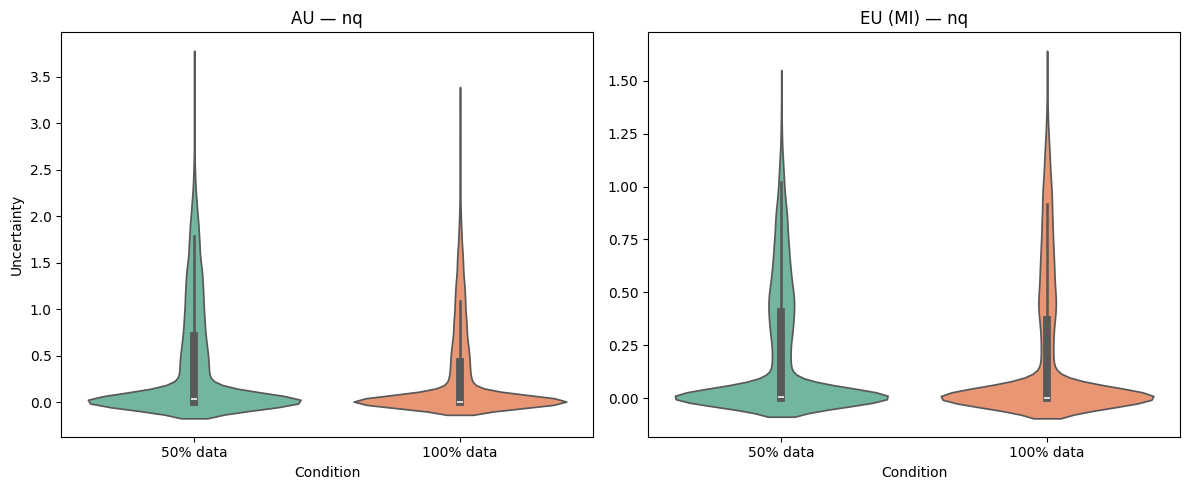

AU: median subset=0.031, full=0.003, p=7.3854e-145, r=-0.166
MI: median subset=0.005, full=0.000, p=7.2275e-63, r=-0.108

setting threshold at 6.176000000000003e-08 to keep 94.99969019146168% (15332 out of 16139)
setting threshold at 1.2523e-06 to keep 94.99394171290096% (14896 out of 15681)


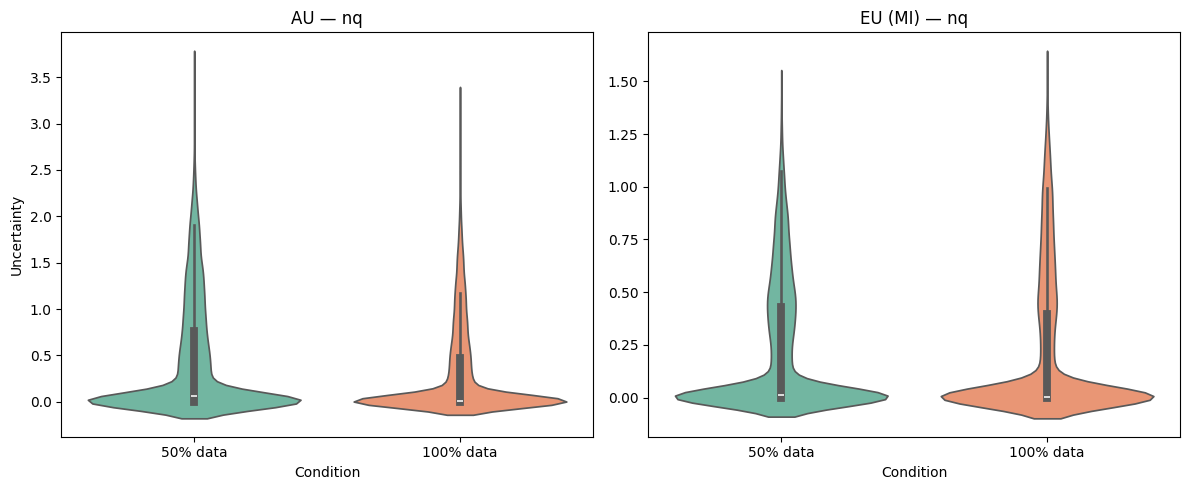

AU: median subset=0.064, full=0.006, p=2.4921e-159, r=-0.179
MI: median subset=0.012, full=0.001, p=9.1132e-68, r=-0.115

setting threshold at 4.000200000000007e-07 to keep 89.99938038292335% (14525 out of 16139)
setting threshold at 6.857100000000001e-06 to keep 89.99426057011671% (14112 out of 15681)


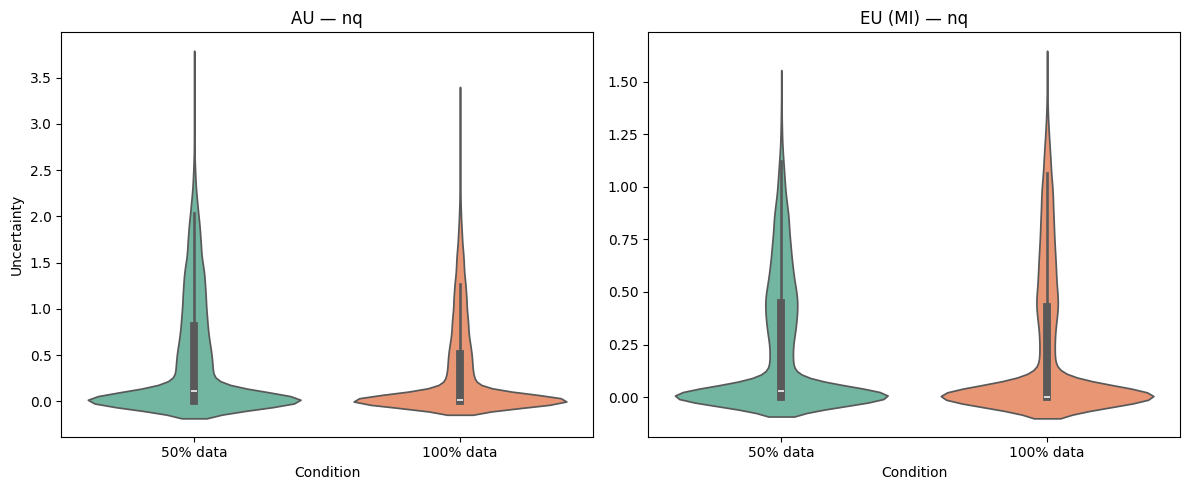

AU: median subset=0.115, full=0.013, p=3.9861e-162, r=-0.185
MI: median subset=0.028, full=0.002, p=1.9426e-65, r=-0.116

setting threshold at 1.4592799999999992e-06 to keep 84.99907057438503% (13718 out of 16139)
setting threshold at 1.8520100000000002e-05 to keep 84.99457942733244% (13328 out of 15681)


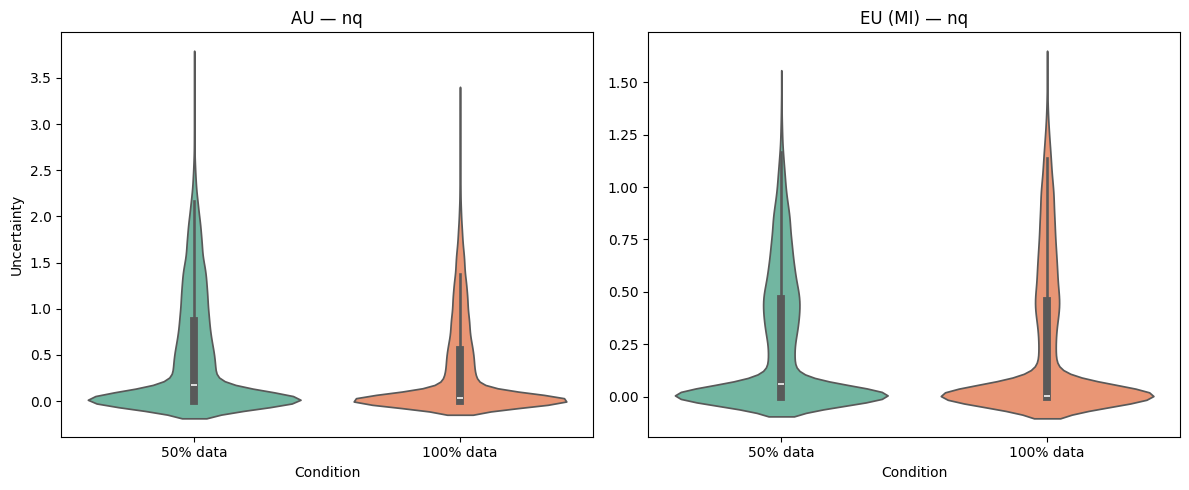

AU: median subset=0.173, full=0.028, p=1.7876e-161, r=-0.190
MI: median subset=0.059, full=0.005, p=5.7347e-61, r=-0.115

setting threshold at 4.430180000000004e-06 to keep 79.99876076584671% (12911 out of 16139)
setting threshold at 4.057e-05 to keep 79.99489828454819% (12544 out of 15681)


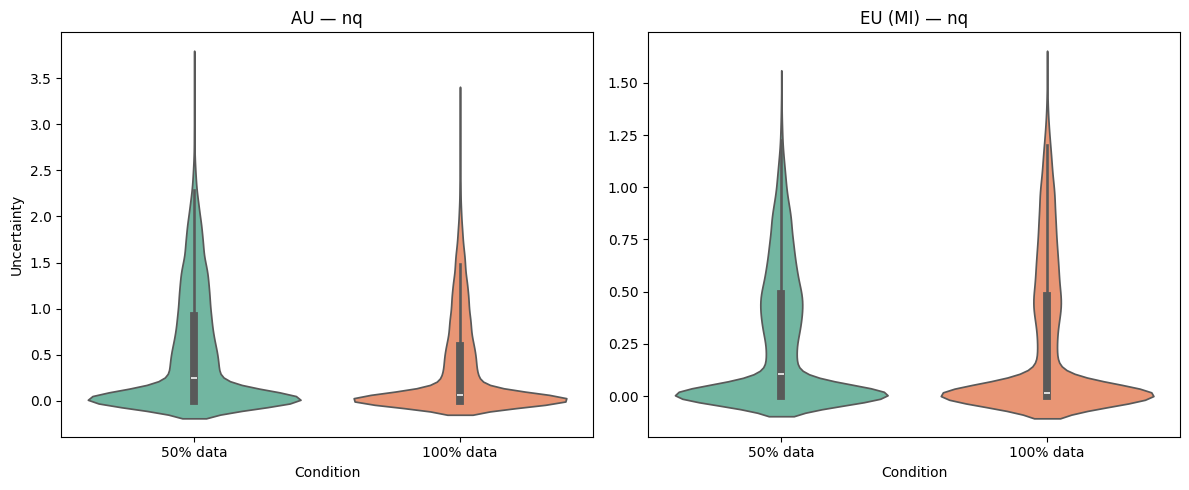

AU: median subset=0.242, full=0.057, p=1.9555e-160, r=-0.195
MI: median subset=0.107, full=0.013, p=5.9817e-56, r=-0.114

setting threshold at 1.147525e-05 to keep 74.99845095730838% (12104 out of 16139)
setting threshold at 9.27958e-05 to keep 74.99521714176392% (11760 out of 15681)


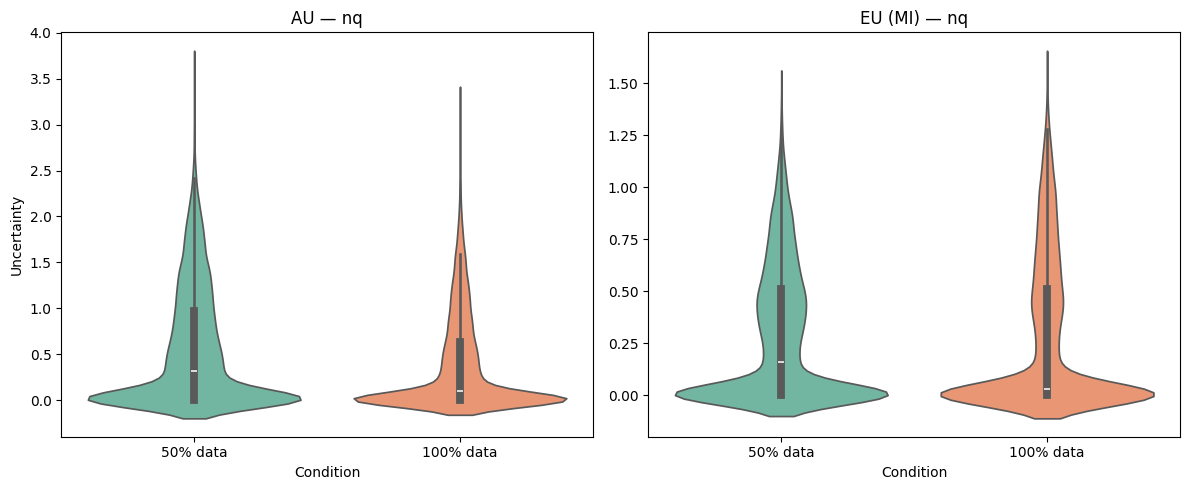

AU: median subset=0.319, full=0.103, p=3.8609e-160, r=-0.202
MI: median subset=0.161, full=0.031, p=9.2172e-51, r=-0.112

setting threshold at 2.8609619999999986e-05 to keep 69.99814114877006% (11297 out of 16139)
setting threshold at 0.0002092211 to keep 69.99553599897966% (10976 out of 15681)


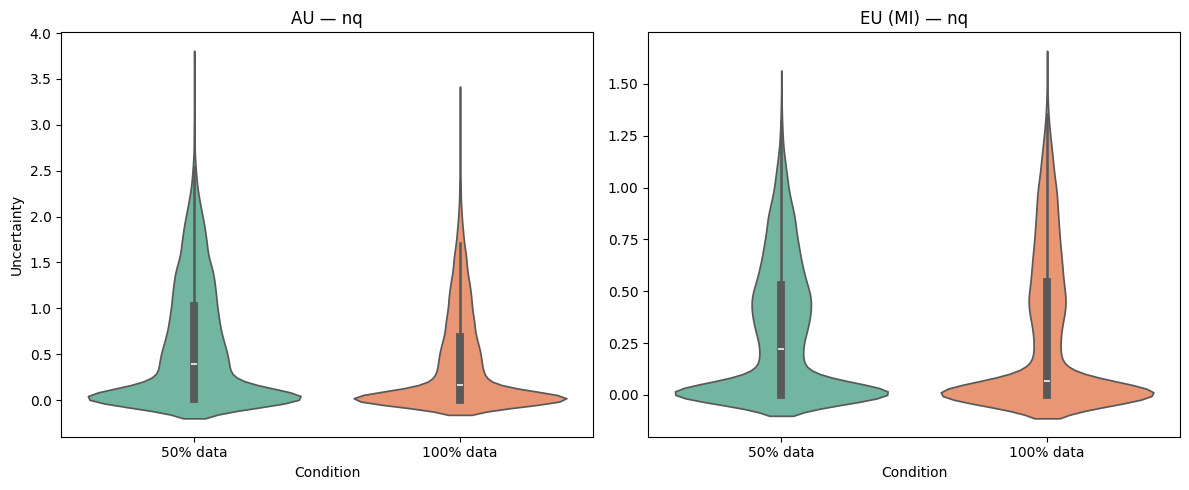

AU: median subset=0.388, full=0.158, p=2.5669e-162, r=-0.210
MI: median subset=0.219, full=0.068, p=1.4673e-45, r=-0.109

setting threshold at 7.457962000000001e-05 to keep 64.99783134023174% (10490 out of 16139)
setting threshold at 0.0005485263 to keep 64.9958548561954% (10192 out of 15681)


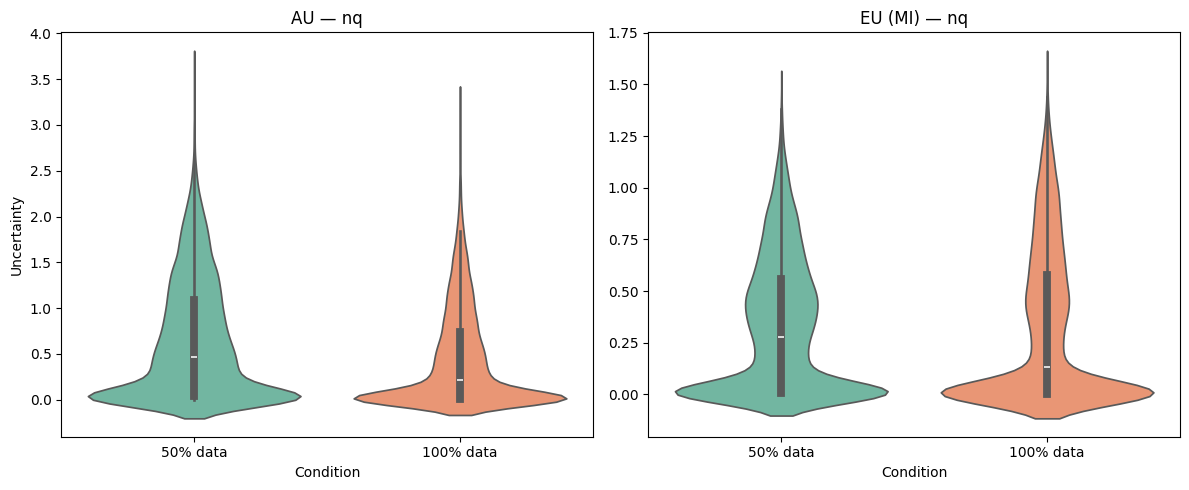

AU: median subset=0.467, full=0.213, p=2.5520e-167, r=-0.221
MI: median subset=0.277, full=0.131, p=6.8970e-41, r=-0.107

setting threshold at 0.00022415642000000004 to keep 59.997521531693415% (9683 out of 16139)
setting threshold at 0.0018488994 to keep 59.99617371341113% (9408 out of 15681)


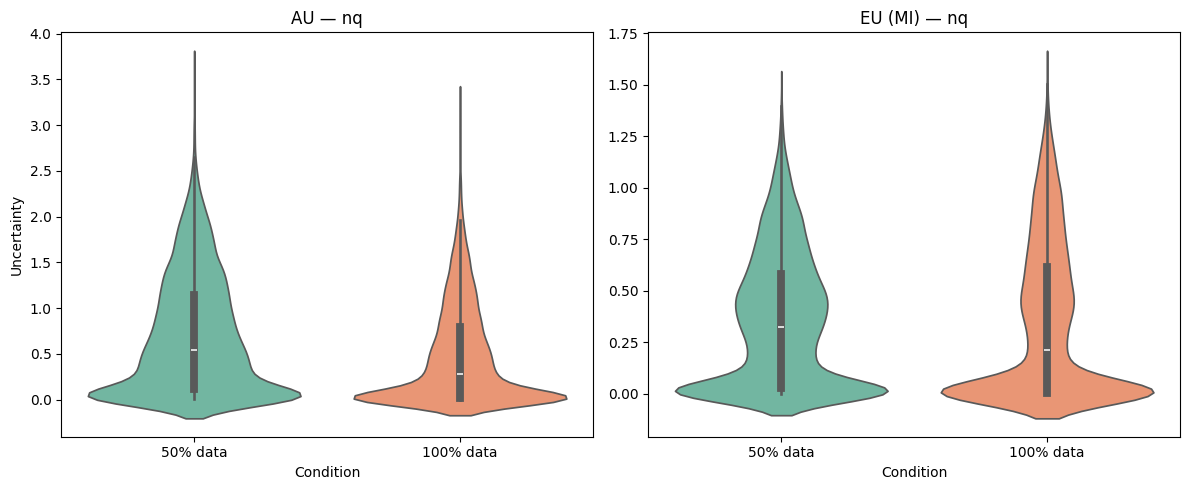

AU: median subset=0.540, full=0.282, p=1.2193e-175, r=-0.236
MI: median subset=0.323, full=0.214, p=1.1256e-35, r=-0.104

setting threshold at 0.0007616254400000001 to keep 54.99721172315509% (8876 out of 16139)
setting threshold at 0.007637756900000001 to keep 54.99649257062687% (8624 out of 15681)


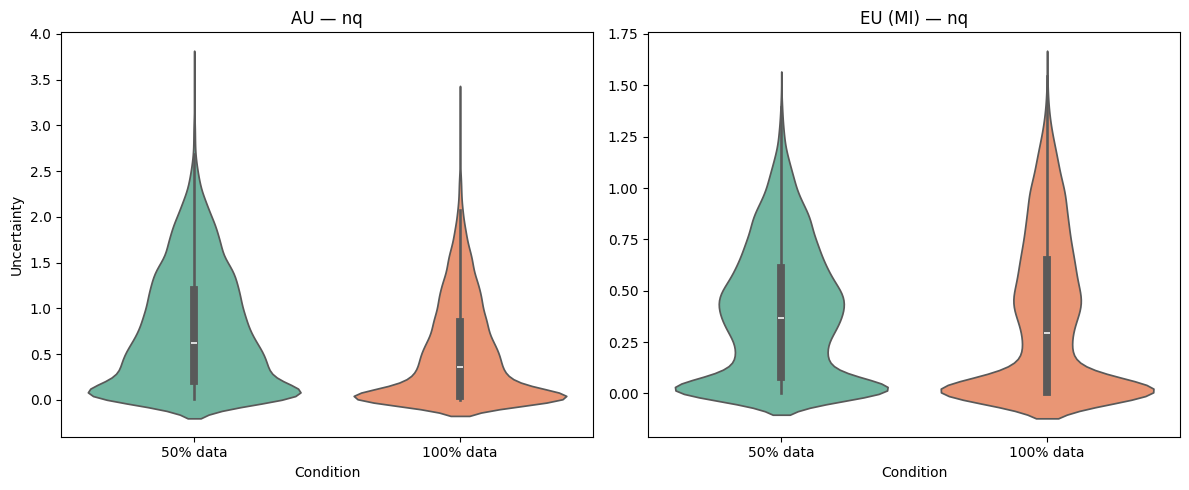

AU: median subset=0.623, full=0.355, p=1.0257e-186, r=-0.254
MI: median subset=0.368, full=0.294, p=9.8394e-30, r=-0.098

setting threshold at 0.003135768 to keep 49.996901914616764% (8069 out of 16139)
setting threshold at 0.0365750529 to keep 49.99681142784261% (7840 out of 15681)


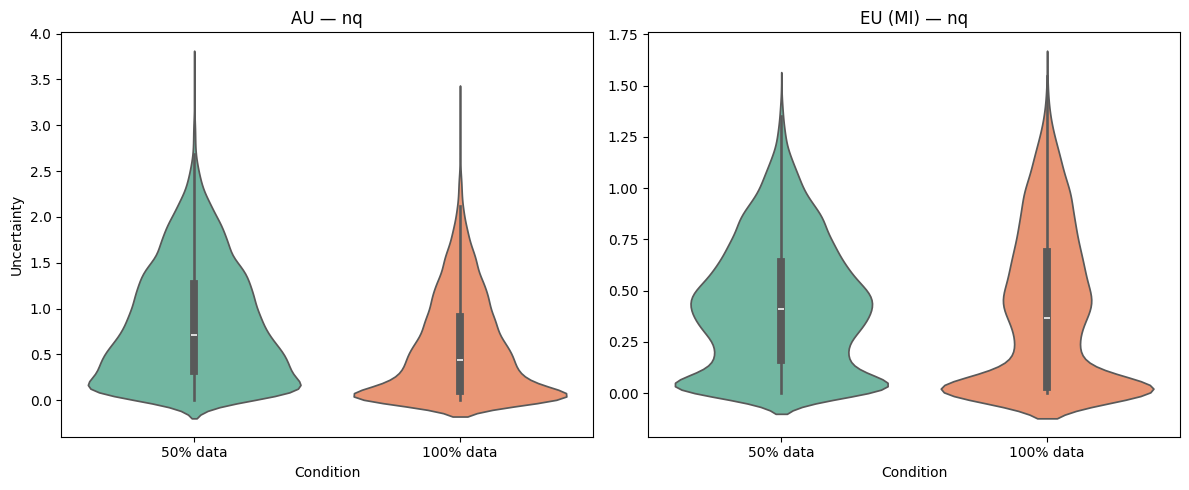

AU: median subset=0.715, full=0.434, p=8.9359e-200, r=-0.276
MI: median subset=0.408, full=0.367, p=1.2694e-22, r=-0.089

setting threshold at 0.015037372070000037 to keep 45.00278827684491% (7263 out of 16139)
setting threshold at 0.1578042656 to keep 44.997130285058354% (7056 out of 15681)


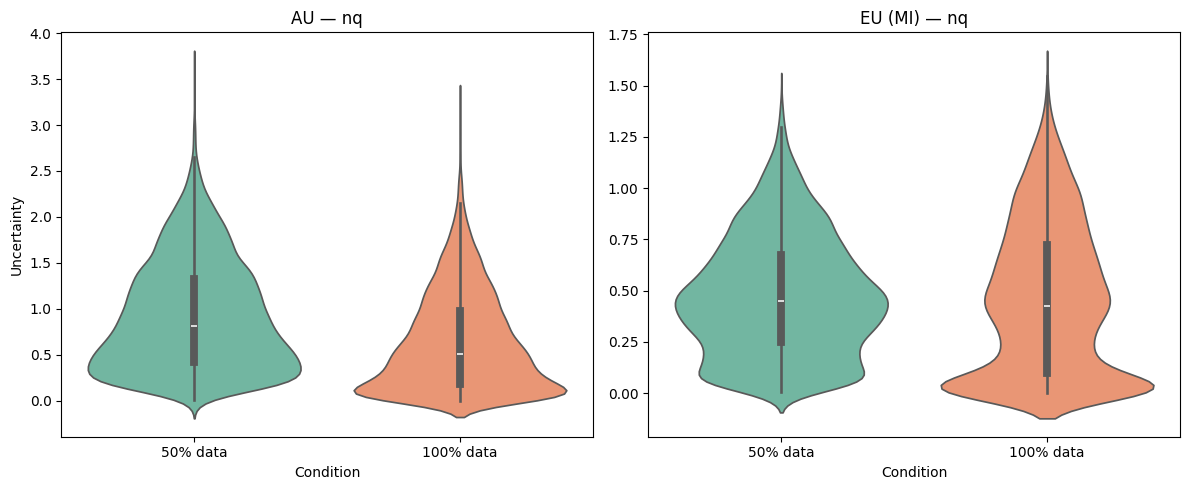

AU: median subset=0.815, full=0.509, p=4.6873e-213, r=-0.301
MI: median subset=0.449, full=0.427, p=2.2116e-14, r=-0.073

setting threshold at 0.07498707619999992 to keep 40.002478468306585% (6456 out of 16139)
setting threshold at 0.4445252418 to keep 39.99744914227409% (6272 out of 15681)


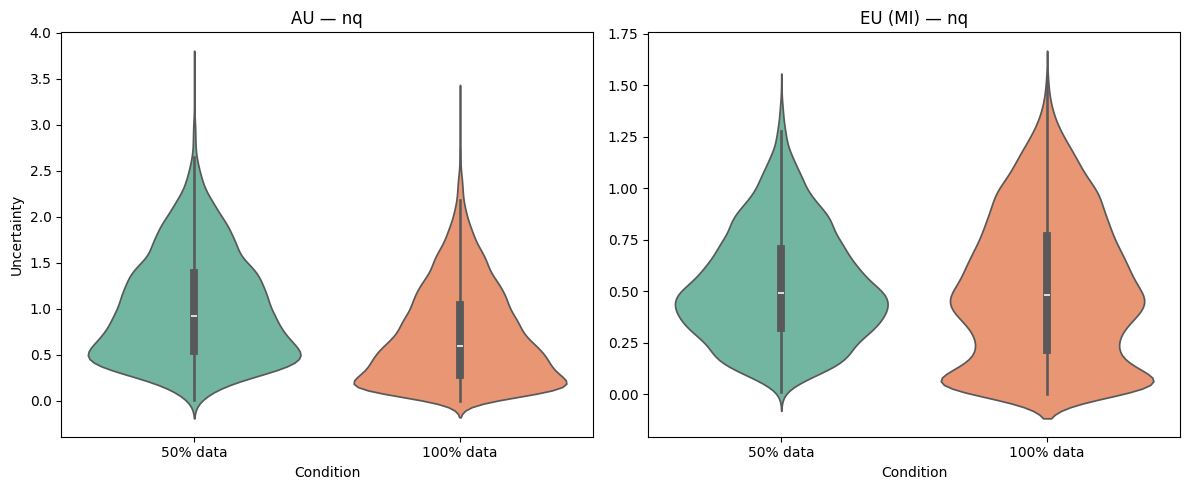

AU: median subset=0.918, full=0.592, p=2.8353e-214, r=-0.320
MI: median subset=0.490, full=0.481, p=3.1041e-06, r=-0.046

setting threshold at 0.2860861212000001 to keep 35.002168659768266% (5649 out of 16139)
setting threshold at 0.6735073328 to keep 34.99776799948983% (5488 out of 15681)


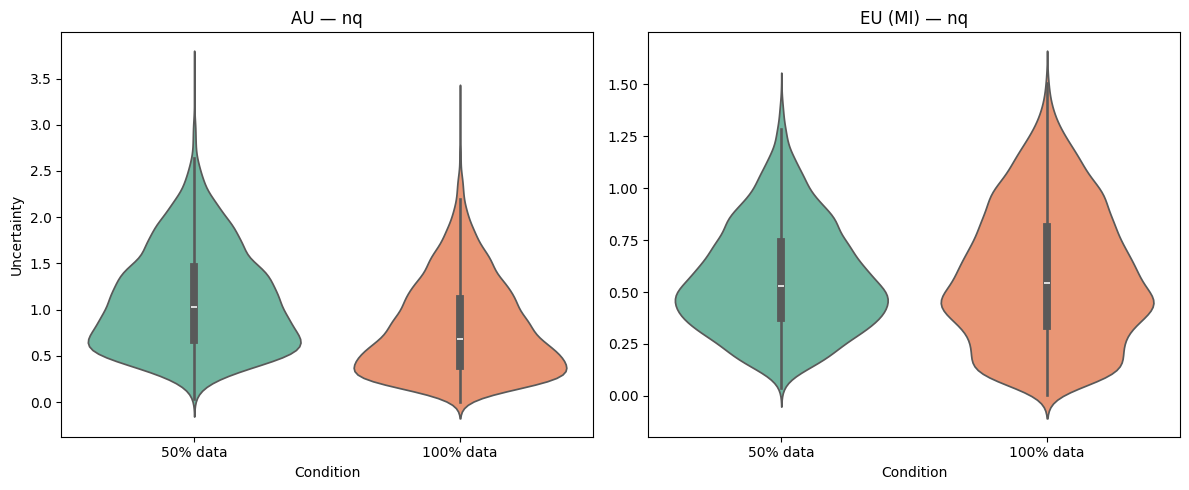

AU: median subset=1.024, full=0.685, p=2.6364e-218, r=-0.345
MI: median subset=0.531, full=0.545, p=7.2365e-01, r=0.006

setting threshold at 0.5785532116800001 to keep 30.00185885122994% (4842 out of 16139)
setting threshold at 0.8984292745 to keep 29.998086856705566% (4704 out of 15681)


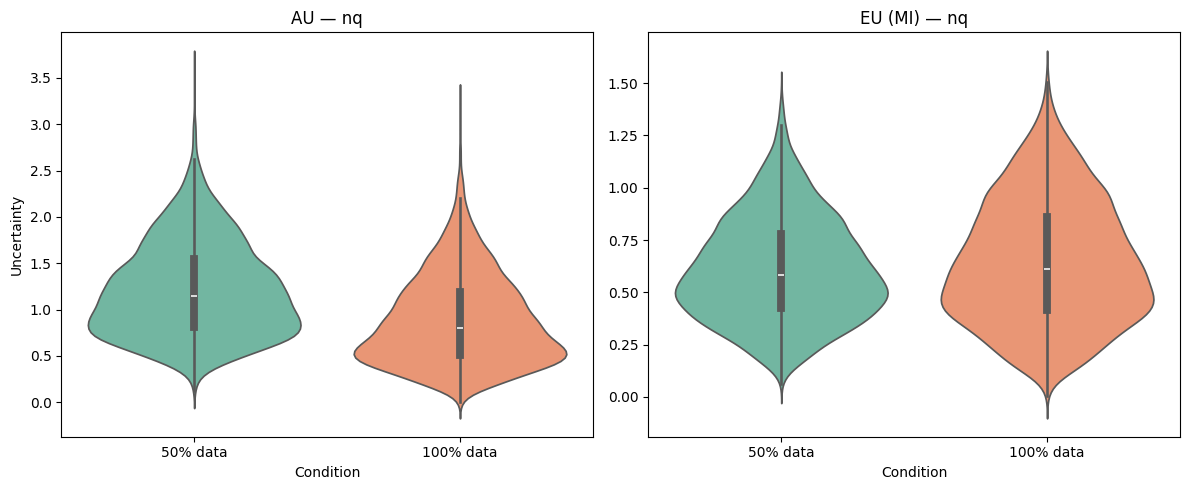

AU: median subset=1.143, full=0.797, p=9.6917e-224, r=-0.377
MI: median subset=0.581, full=0.614, p=1.0000e+00, r=0.058

0.12188365650969529


In [7]:
def load_results_subset(method: str, dataset: str, percentile: int) -> dict[str, np.ndarray]:
    results = {}
    # full model
    path_full = Path("../results") / dataset / f"{method}-hard-token.jsonl"
    results["hard-au"], results["hard-mi"] = read_uncertainties(path_full, percentile)
    # subset model (0.5)
    path_subset = Path("../results") / dataset / f"{method}-hard-0.1-token.jsonl"  # adjust filename
    results["subset-au"], results["subset-mi"] = read_uncertainties(path_subset, percentile)
    return results


def perform_subset_test(results: dict) -> None:
    for key, label in [("au", "AU"), ("mi", "MI")]:
        subset = results[f"subset-{key}"]
        full = results[f"hard-{key}"]
        # hypothesis: less data -> higher EU (one-sided), AU should not change (two-sided)
        alternative = "greater" if key == "mi" else "two-sided"
        stat, p = mannwhitneyu(subset, full, alternative=alternative)
        r = 1 - (2 * stat) / (len(subset) * len(full))
        print(f"{label}: median subset={np.median(subset):.3f}, full={np.median(full):.3f}, p={p:.4e}, r={r:.3f}")


def draw_subset(results: dict, dataset: str) -> None:
    df_au = pd.DataFrame({
        "Value":     list(results["subset-au"]) + list(results["hard-au"]),
        "Condition": ["50% data"] * len(results["subset-au"]) + ["100% data"] * len(results["hard-au"])
    })
    df_mi = pd.DataFrame({
        "Value":     list(results["subset-mi"]) + list(results["hard-mi"]),
        "Condition": ["50% data"] * len(results["subset-mi"]) + ["100% data"] * len(results["hard-mi"])
    })
    _, axs = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)
    sns.violinplot(data=df_au, x="Condition", y="Value", hue="Condition",
                   inner="box", palette="Set2", legend=False, ax=axs[0])
    sns.violinplot(data=df_mi, x="Condition", y="Value", hue="Condition",
                   inner="box", palette="Set2", legend=False, ax=axs[1])
    axs[0].set_title(f"AU — {dataset}")
    axs[1].set_title(f"EU (MI) — {dataset}")
    axs[0].set_ylabel("Uncertainty")
    axs[1].set_ylabel("")
    plt.show()


for dataset in ("nq",):
    for percentile in range(0, 75, 5):
        results = load_results_subset("ensemble5", dataset, percentile)
        draw_subset(results, dataset)
        perform_subset_test(results)
        print()
import sys
sys.path.insert(0, "..")

from src.eval.utils import exact_match


path = Path("../results") / "nq" / "ensemble5-hard-0.1-token.jsonl"
df = pd.read_json(path, lines=True)
df["em"] = df.apply(lambda r: exact_match(r["prediction"], r["answers"]), axis=1)
print(df["em"].mean())